In [294]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [295]:
file_path = "/content/sample_data/telco_customer_churn.csv"
df = pd.read_csv(file_path)

In [296]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [297]:
print(df.shape)
print(df.columns.tolist())

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [298]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [299]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [300]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


Data Cleaning


In [301]:
converted = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.loc[:, "TotalCharges"] = converted

df["TotalCharges"].isnull().sum()

np.int64(11)

In [302]:
#fill missing values with the median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df.isnull().sum()

/tmp/ipykernel_1147/3368791168.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [303]:
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(lambda col: col.astype(str).str.strip())

In [304]:
#Convert the target column to numeric
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [305]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [306]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-" * 50)

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender
['Female' 'Male']
--------------------------------------------------
SeniorCitizen
[0 1]
--------------------------------------------------
Partner
['Yes' 'No']
--------------------------------------------------
Dependents
['No' 'Yes']
--------------------------------------------------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService
['No' 'Yes']
--------------------------------------------------
MultipleLines
['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSec

Data exploring

In [307]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
0,37.569965
1,17.979133


In [308]:
df['CLV'] = df['MonthlyCharges'] * df['tenure']

In [309]:
service_cols = [
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
df['ServicesCount'] = df[service_cols].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}).sum(axis=1)

/tmp/ipykernel_1147/1206574314.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ServicesCount'] = df[service_cols].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}).sum(axis=1)


In [310]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CLV,ServicesCount
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.85,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,0,1936.30,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,107.70,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,1903.50,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,141.40,1


In [311]:
ranks = df['CLV'].rank(method='first')
df['CLV_Rank'] = pd.qcut(ranks, q=4, labels=['Low', 'Mid', 'High', 'Top'])

In [312]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,CLV,ServicesCount
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370,2279.581350,3.362914
std,0.368612,24.559481,30.090047,2265.270398,0.441561,2264.729447,2.062031
min,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000,394.000000,1.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000,1393.600000,3.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000,3786.100000,5.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,8550.000000,8.000000


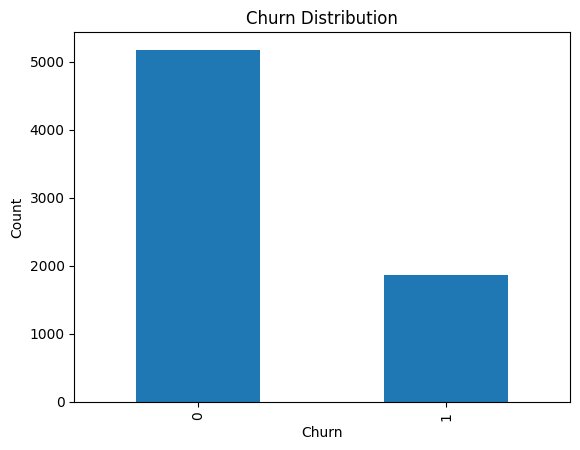

In [313]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [314]:
# to capture average spending intensity
df['AvgRevenuePerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
df['AvgRevenuePerMonth'] = df['AvgRevenuePerMonth'].round(2)

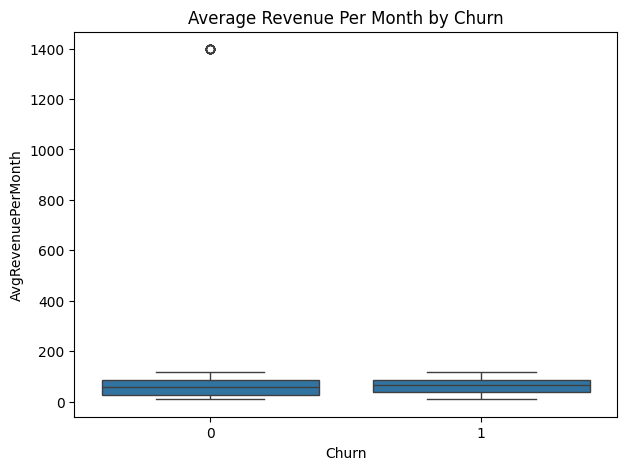

In [315]:
import seaborn as sns
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='AvgRevenuePerMonth')
plt.title('Average Revenue Per Month by Churn')
plt.xlabel('Churn')
plt.ylabel('AvgRevenuePerMonth')
plt.show()

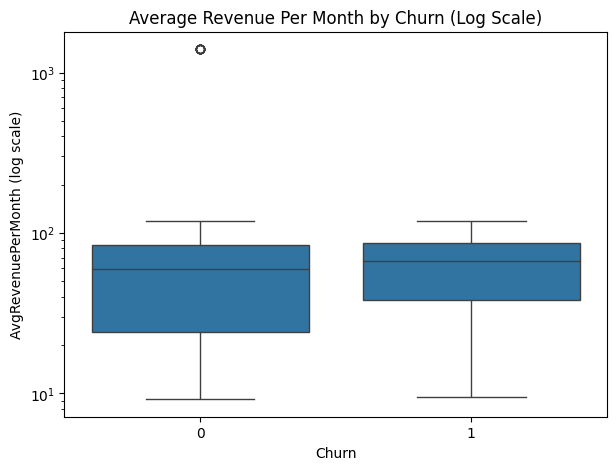

In [316]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='AvgRevenuePerMonth')
plt.yscale('log')
plt.title('Average Revenue Per Month by Churn (Log Scale)')
plt.xlabel('Churn')
plt.ylabel('AvgRevenuePerMonth (log scale)')
plt.show()

**Graphs for catagoeical variables to understand the data**

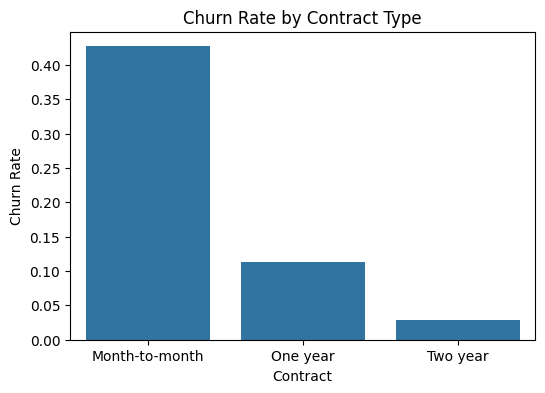

In [317]:
import seaborn as sns
import matplotlib.pyplot as plt

churn_rate = df.groupby('Contract', as_index=False)['Churn'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x='Contract', y='Churn', data=churn_rate)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

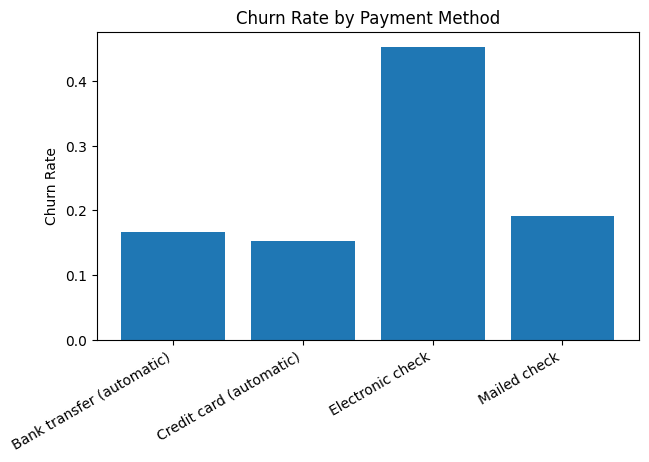

In [318]:
churn_by_payment = df.groupby('PaymentMethod')['Churn'].mean()
plt.figure(figsize=(7,4))
plt.bar(churn_by_payment.index, churn_by_payment.values)
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=30, ha='right')
plt.show()

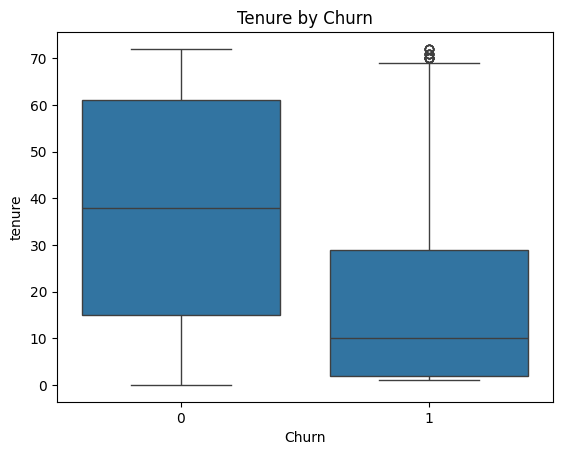

In [319]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure by Churn')
plt.show()

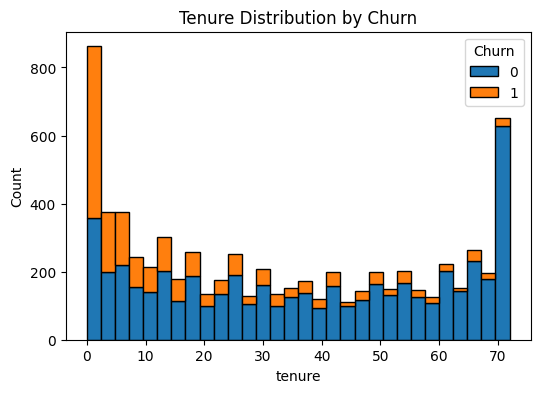

In [320]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(
    [df[df['Churn'] == 0]['tenure'], df[df['Churn'] == 1]['tenure']],
    bins=30,
    stacked=True,
    label=['0', '1'],
    edgecolor='black'
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('tenure')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

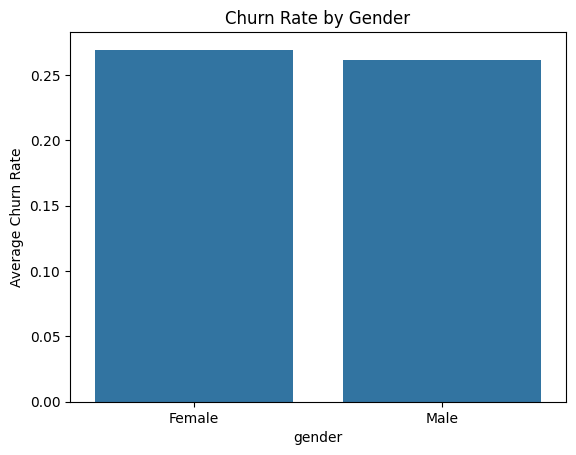

In [321]:

churn_by_gender = df.groupby('gender')['Churn'].mean().reset_index()
sns.barplot(data=churn_by_gender, x='gender', y='Churn')
plt.title('Churn Rate by Gender')
plt.ylabel('Average Churn Rate')
plt.show()


In [322]:
df['HasFiber'] = np.where(df['InternetService'] == 'Fiber optic', 1, 0)
df['IsMonthToMonth'] = np.where(df['Contract'] == 'Month-to-month', 1, 0)
df['IsElectronicCheck'] = np.where(df['PaymentMethod'] == 'Electronic check', 1, 0)

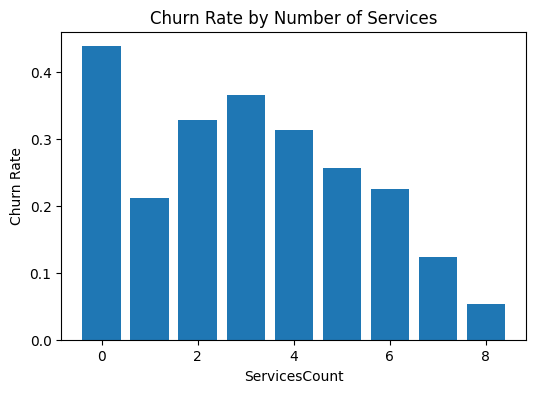

In [323]:
import matplotlib.pyplot as plt

churn_rate = df.groupby('ServicesCount')['Churn'].mean()

plt.figure(figsize=(6,4))
plt.bar(churn_rate.index, churn_rate.values)
plt.title('Churn Rate by Number of Services')
plt.xlabel('ServicesCount')
plt.ylabel('Churn Rate')
plt.show()

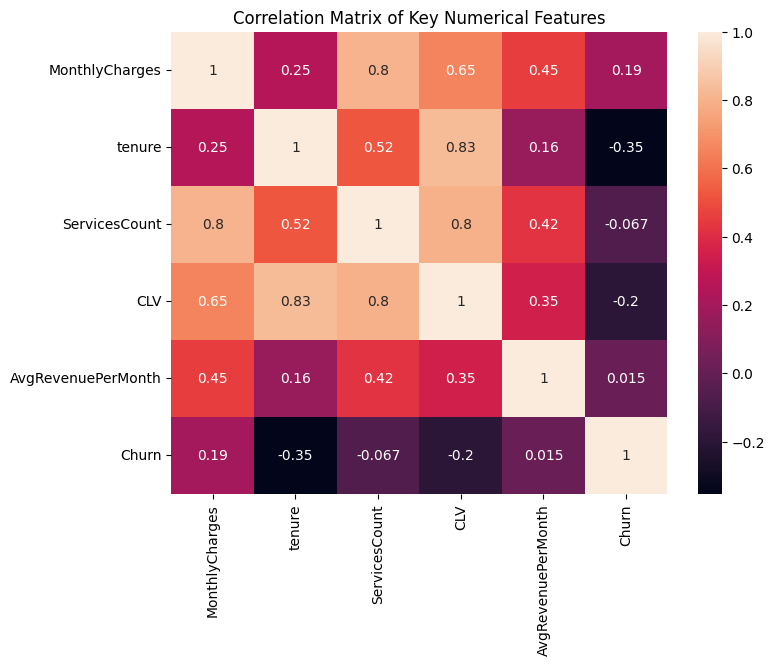

In [324]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['MonthlyCharges','tenure','ServicesCount','CLV','AvgRevenuePerMonth','Churn']].corr(), annot=True)
plt.title('Correlation Matrix of Key Numerical Features')
plt.show()

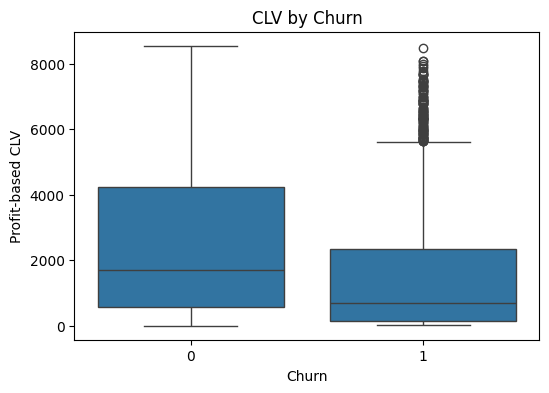

In [325]:

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='CLV', data=df)
plt.title('CLV by Churn')
plt.ylabel('Profit-based CLV')
plt.show()

**Model Building**

In [326]:
Variables_formodel = [
    'gender','SeniorCitizen','Partner','Dependents', 'PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','MonthlyCharges','tenure','ServicesCount','HasFiber','IsMonthToMonth','IsElectronicCheck'
]
print(" features :", len(Variables_formodel))

 features : 22


In [327]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
target_col = 'Churn'
feature_cols = Variables_formodel

y = df.loc[:, target_col]
X = df.loc[:, feature_cols]
cat_cols = [col for col in X.columns if X[col].dtype == 'object']
num_cols = [col for col in X.columns if X[col].dtype != 'object']
print("Categorical:", cat_cols)
print("Numeric:", num_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocess = ColumnTransformer(
    [
        ("categorical_encoding",
         OneHotEncoder(drop="first", handle_unknown="ignore"),
         cat_cols),

        ("numerical_pass",
         "passthrough",
         num_cols)
    ]
)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['SeniorCitizen', 'MonthlyCharges', 'tenure', 'ServicesCount', 'HasFiber', 'IsMonthToMonth', 'IsElectronicCheck']


In [328]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=300,
    solver='liblinear'
)

pipeline_steps = [
    ("preprocessor", preprocess),
    ("classifier", log_reg)
]

model = Pipeline(pipeline_steps)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical_encoding',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('numerical_pass',
                                                  'passthrough',
                                                  ['SeniorCitizen',
                                                   'MonthlyCharges', 'tenure',
                                                   'ServicesCount', 'HasFiber',
                                                   'IsMonthToMonth',
                                                   'IsElectronicCheck'])])),
                ('classifier',
                 LogisticRegression(max_iter=300, solver='liblinear'))])

In [329]:
# to find the best threshold
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.61, 0.01)

results = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    results.append((t, f1))

results_df = pd.DataFrame(results, columns=['threshold', 'f1_score'])

best_row = results_df.loc[results_df['f1_score'].idxmax()]

best_threshold = best_row['threshold']
best_f1 = best_row['f1_score']

print("Best threshold:", round(best_threshold, 2))
print("Best F1 score:", round(best_f1, 4))

results_df.sort_values('f1_score', ascending=False).head(10)

Best threshold: 0.27
Best F1 score: 0.63


,threshold,f1_score
17,0.27,0.630043
24,0.34,0.626977
23,0.33,0.626617
20,0.30,0.624667
30,0.40,0.624381
18,0.28,0.624348
16,0.26,0.624258
19,0.29,0.624126
25,0.35,0.623474
21,0.31,0.623423


Threshold: 0.27

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.74      0.82      1294
           1       0.53      0.79      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.72      1761
weighted avg       0.81      0.76      0.77      1761

ROC AUC: 0.844


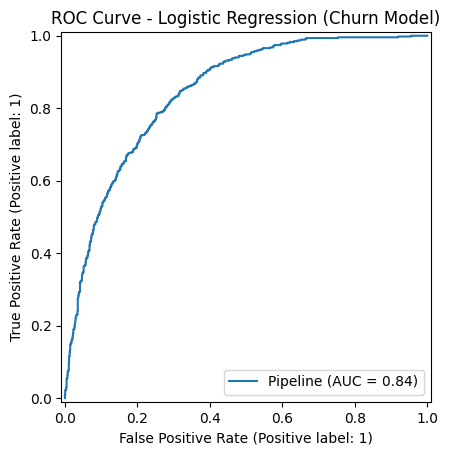

In [330]:

threshold = 0.27
y_pred = (y_pred_proba >= threshold).astype(int)
print("Threshold:", threshold)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", round(roc_auc_score(y_test, y_pred_proba), 3))
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve - Logistic Regression (Churn Model)")
plt.show()

In [331]:
#important features
trained_preprocessor = model.named_steps['preprocessor']
trained_classifier = model.named_steps['classifier']
encoder = trained_preprocessor.named_transformers_['categorical_encoding']
encoded_cat_names = encoder.get_feature_names_out(cat_cols)
final_feature_names = np.r_[encoded_cat_names, num_cols]
coef_values = trained_classifier.coef_.ravel()
feature_importance = (
    pd.DataFrame({
        'feature': final_feature_names,
        'coefficient': coef_values
    })
    .assign(abs_coeff=lambda x: x['coefficient'].abs())
    .sort_values('abs_coeff', ascending=False)
)

print(feature_importance.head(9))

                        feature  coefficient  abs_coeff
6   InternetService_Fiber optic     0.879469   0.879469
30                     HasFiber     0.879469   0.879469
21            Contract_Two year    -0.644885   0.644885
31               IsMonthToMonth     0.635124   0.635124
19          StreamingMovies_Yes     0.464363   0.464363
9            OnlineSecurity_Yes    -0.424439   0.424439
17              StreamingTV_Yes     0.407263   0.407263
22         PaperlessBilling_Yes     0.400750   0.400750
15              TechSupport_Yes    -0.373865   0.373865


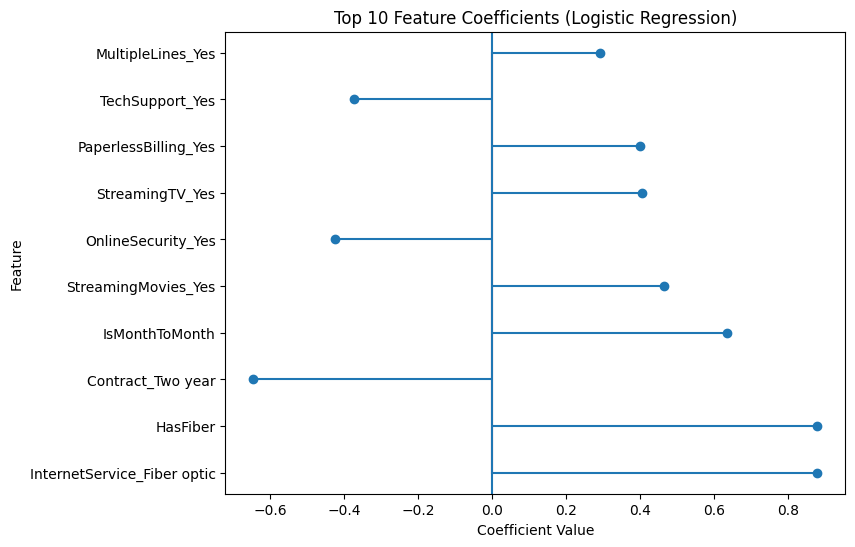

In [332]:
import matplotlib.pyplot as plt

top_feats = feature_importance.head(10)

plt.figure(figsize=(8,6))
markerline, stemlines, baseline = plt.stem(
    top_feats['coefficient'],
    orientation='horizontal'
)

plt.yticks(range(len(top_feats)), top_feats['feature'])
plt.axvline(0)

plt.title('Top 10 Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

**Which customers are both likely to churn and highly valuable?**

Those are the customers the company should focus on.


In [333]:
results_table = (
    X_test
    .assign(
        churn_prob=y_pred_proba,
        actual_churn=y_test.to_numpy(),
        CLV_segment=df.loc[X_test.index, 'CLV_Rank'],
        CLV_realized_margin=df.loc[X_test.index, 'CLV']
    )
)

results_table.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,tenure,ServicesCount,HasFiber,IsMonthToMonth,IsElectronicCheck,churn_prob,actual_churn,CLV_segment,CLV_realized_margin
5909,Female,0,No,No,Yes,Yes,Fiber optic,No,Yes,No,...,80.20,52,3,1,0,0,0.170030,0,Top,4170.40
3670,Female,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,...,24.25,33,2,0,1,0,0.067397,0,Mid,800.25
6220,Male,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,Yes,...,53.70,10,5,0,0,0,0.056578,0,Mid,537.00
5905,Male,0,No,No,Yes,No,Fiber optic,No,Yes,No,...,85.00,1,3,1,1,1,0.730647,0,Low,85.00
6435,Male,0,Yes,Yes,No,No phone service,DSL,No,Yes,Yes,...,50.20,52,4,0,0,0,0.023691,0,High,2610.40


In [334]:
risk_threshold = 0.6

mask = (
    (results_table['churn_prob'] >= risk_threshold) &
    (results_table['CLV_segment'].isin(['High', 'Top']))
)

priority_customers = results_table.loc[mask].copy()

print(f"High-value & high-risk customers: {len(priority_customers)}")

priority_customers.loc[:,
    ['MonthlyCharges','tenure','ServicesCount','churn_prob','CLV_segment']
].head()

High-value & high-risk customers: 58


,MonthlyCharges,tenure,ServicesCount,churn_prob,CLV_segment
2516,96.40,16,4,0.794134,High
3792,91.25,26,3,0.672274,High
3918,90.20,20,3,0.630361,High
2448,104.85,14,6,0.789160,High
4947,98.35,26,5,0.721440,High


Who are the most valuable customers overall?

/tmp/ipykernel_1147/3420784954.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_churn = results_table.groupby('CLV_segment')['churn_prob'].mean()


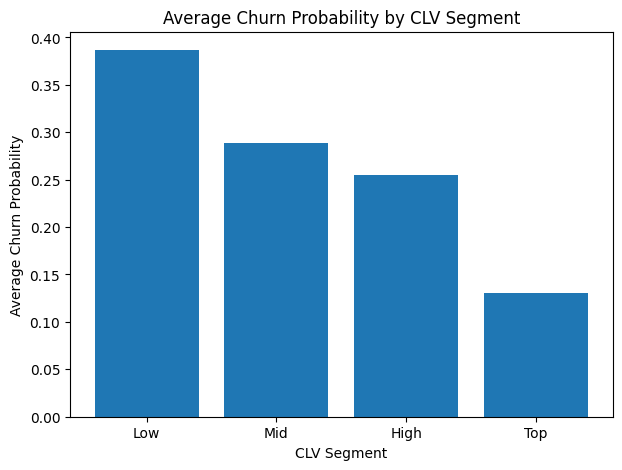

In [335]:
import matplotlib.pyplot as plt

avg_churn = results_table.groupby('CLV_segment')['churn_prob'].mean()

plt.figure(figsize=(7,5))
plt.bar(avg_churn.index, avg_churn.values)

plt.title('Average Churn Probability by CLV Segment')
plt.xlabel('CLV Segment')
plt.ylabel('Average Churn Probability')
plt.show()

In [336]:
df['AvgRevenuePerMonth_Rank'] = pd.qcut(df['AvgRevenuePerMonth'], q=4, labels=['Low','Mid','High','Top'])

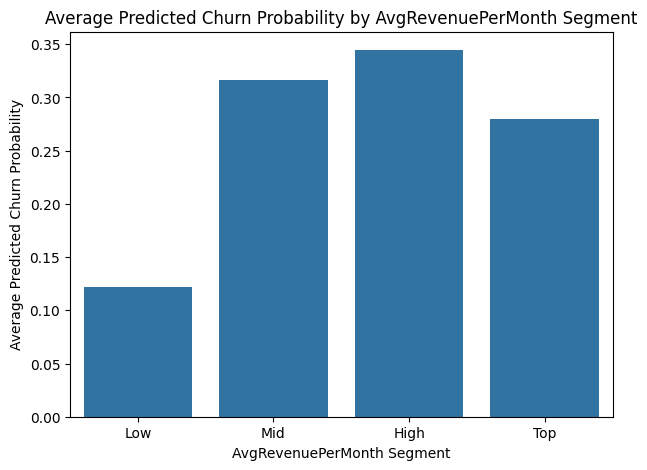

In [337]:
df['AvgRevenuePerMonth_Rank'] = pd.qcut(
    df['AvgRevenuePerMonth'],
    q=4,
    labels=['Low', 'Mid', 'High', 'Top']
)

# attach predicted probabilities from logistic regression
df.loc[X_test.index, 'log_prob'] = y_pred_proba

avg_rev_rank_prob = (
    df.loc[X_test.index]
      .groupby('AvgRevenuePerMonth_Rank', observed=False)['log_prob']
      .mean()
      .reset_index()
)

plt.figure(figsize=(7,5))
sns.barplot(data=avg_rev_rank_prob, x='AvgRevenuePerMonth_Rank', y='log_prob')
plt.title('Average Predicted Churn Probability by AvgRevenuePerMonth Segment')
plt.xlabel('AvgRevenuePerMonth Segment')
plt.ylabel('Average Predicted Churn Probability')
plt.show()

In [338]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Churn,CLV,ServicesCount,CLV_Rank,AvgRevenuePerMonth,HasFiber,IsMonthToMonth,IsElectronicCheck,AvgRevenuePerMonth_Rank,log_prob
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,0,29.85,1,Low,14.92,0,1,1,Low,NaN
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,0,1936.30,3,High,53.99,0,0,0,Mid,NaN
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,1,107.70,3,Low,36.05,0,1,0,Mid,NaN
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,0,1903.50,3,High,40.02,0,0,0,Mid,NaN
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,141.40,1,Low,50.55,1,1,1,Mid,NaN


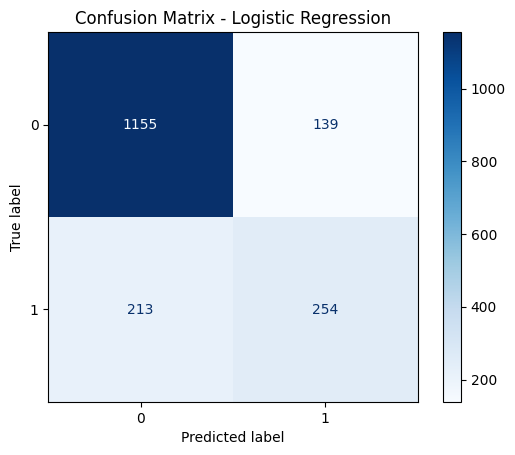

In [339]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

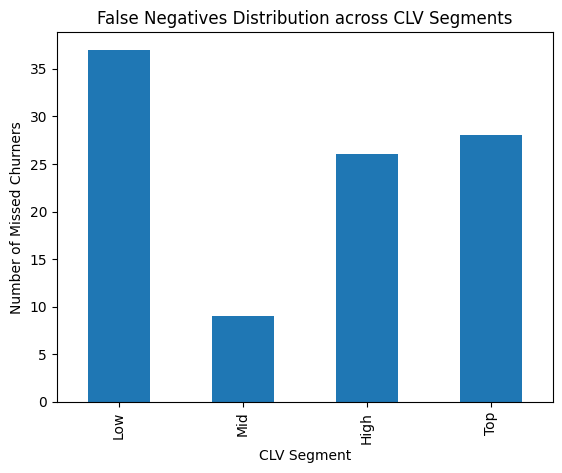

In [340]:
eval_df = X_test.copy()
eval_df['actual_churn'] = y_test
eval_df['predicted'] = (y_pred_proba >= 0.27).astype(int)
eval_df['prob'] = y_pred_proba
eval_df['CLV'] = df.loc[X_test.index, 'CLV']
eval_df['AvgRevenuePerMonth'] = df.loc[X_test.index, 'AvgRevenuePerMonth']

eval_df['CLV_segment'] = pd.qcut(
    eval_df['CLV'],
    q=4,
    labels=['Low','Mid','High','Top']
)

eval_df['AvgRevenuePerMonth_Rank'] = df.loc[X_test.index, 'AvgRevenuePerMonth_Rank']

false_negatives = eval_df[
    (eval_df['actual_churn'] == 1) &
    (eval_df['predicted'] == 0)
]

fn_distribution = false_negatives['CLV_segment'].value_counts().sort_index()

fn_distribution.plot(kind='bar')
plt.title('False Negatives Distribution across CLV Segments')
plt.xlabel('CLV Segment')
plt.ylabel('Number of Missed Churners')
plt.show()

In [341]:
false_negatives.groupby('AvgRevenuePerMonth_Rank')['AvgRevenuePerMonth'].count()

/tmp/ipykernel_1147/3380743013.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  false_negatives.groupby('AvgRevenuePerMonth_Rank')['AvgRevenuePerMonth'].count()


,AvgRevenuePerMonth
AvgRevenuePerMonth_Rank,
Low,30
Mid,28
High,12
Top,30


**Random Forest Model**

In [342]:
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.ensemble import RandomForestClassifier as RF

rf_estimator = RF(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    class_weight='balanced'
)

pipeline_components = [
    ("data_processing", preprocess),
    ("rf_model", rf_estimator)
]

rf_pipeline = SkPipeline(pipeline_components)

Best Threshold: 0.42
Best F1-Score: 0.635


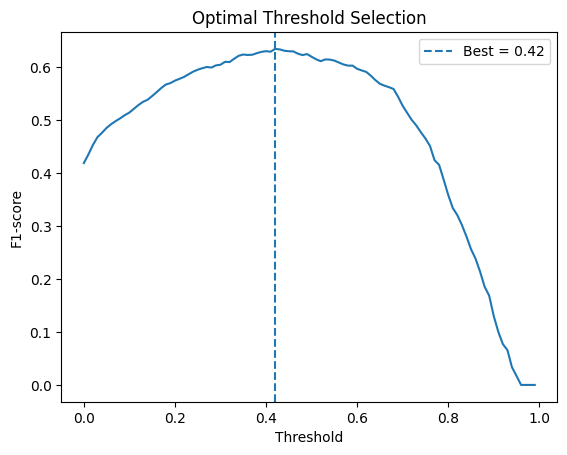

In [343]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
rf_pipeline.fit(X_train, y_train)
proba_scores = rf_pipeline.predict_proba(X_test)[:, 1]
threshold_grid = np.linspace(0, 0.99, 100)
f1_list = []
for thr in threshold_grid:
    preds = (proba_scores >= thr).astype(int)
    f1_list.append(f1_score(y_test, preds))

best_idx = np.argmax(f1_list)
opt_threshold = threshold_grid[best_idx]
opt_f1 = f1_list[best_idx]

print("Best Threshold:", round(opt_threshold, 3))
print("Best F1-Score:", round(opt_f1, 3))

plt.plot(threshold_grid, f1_list)
plt.axvline(opt_threshold, linestyle='--', label=f"Best = {opt_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Optimal Threshold Selection")
plt.legend()
plt.show()


Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1294
           1       0.53      0.79      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.76      0.77      1761

ROC AUC (Random Forest): 0.84


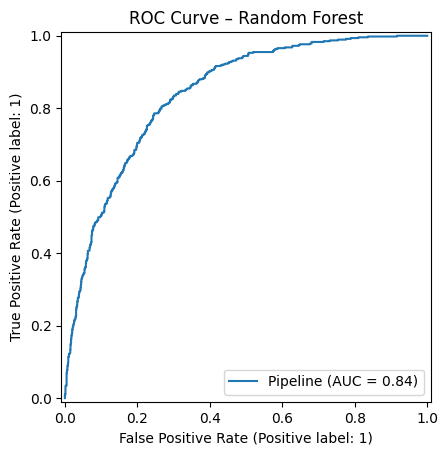

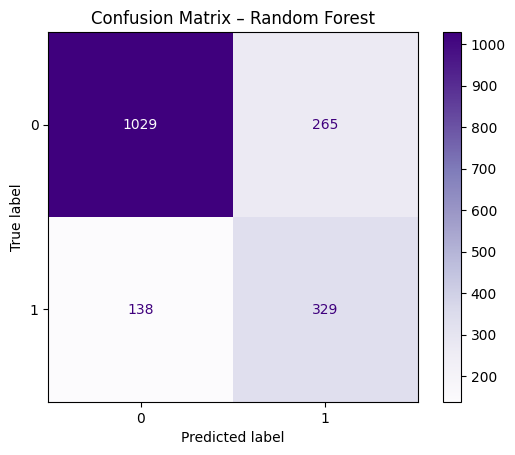

In [344]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

rf_pipeline.fit(X_train, y_train)
rf_prob_scores = rf_pipeline.predict_proba(X_test)[:, 1]
rf_predictions = (rf_prob_scores >= 0.42).astype(int)
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, rf_predictions))

auc_value = roc_auc_score(y_test, rf_prob_scores)
print("ROC AUC (Random Forest):", round(auc_value, 3))
roc_plot = RocCurveDisplay.from_estimator(rf_pipeline, X_test, y_test)
plt.title("ROC Curve – Random Forest")
plt.show()
cm_plot = ConfusionMatrixDisplay.from_estimator(
    rf_pipeline,
    X_test,
    y_test,
    cmap='Purples'
)
plt.title("Confusion Matrix – Random Forest")
plt.show()


Top 10 Random Forest Features:

                           feature  importance
28                          tenure    0.186956
31                  IsMonthToMonth    0.131621
27                  MonthlyCharges    0.115107
21               Contract_Two year    0.061023
30                        HasFiber    0.042935
6      InternetService_Fiber optic    0.039928
29                   ServicesCount    0.037031
32               IsElectronicCheck    0.032035
24  PaymentMethod_Electronic check    0.029373
9               OnlineSecurity_Yes    0.025747


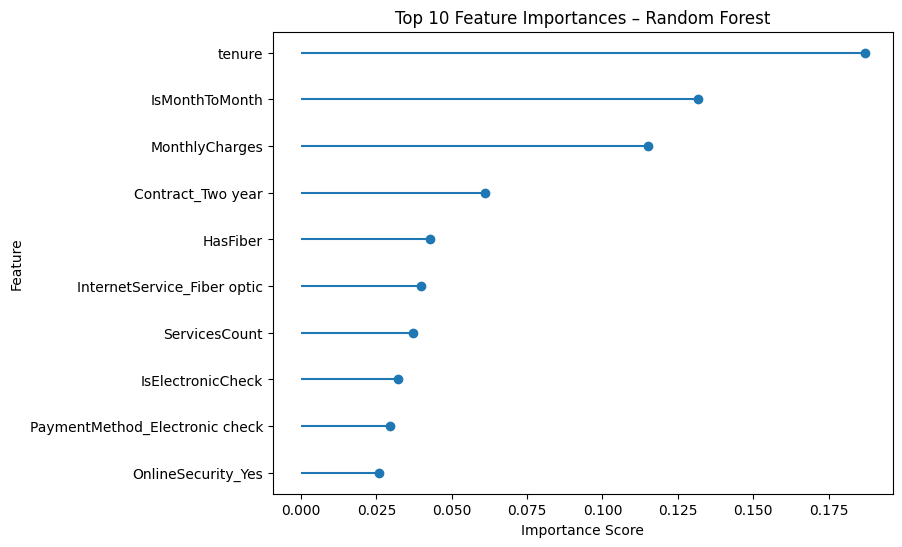

In [345]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fitted_encoder = rf_pipeline.named_steps['data_processing'].named_transformers_['categorical_encoding']
forest_estimator = rf_pipeline.named_steps['rf_model']
encoded_names = fitted_encoder.get_feature_names_out(cat_cols)
final_rf_columns = np.r_[encoded_names, num_cols]
rf_feature_imp = (
    pd.DataFrame(
        zip(final_rf_columns, forest_estimator.feature_importances_),
        columns=['feature', 'importance']
    )
    .sort_values('importance', ascending=False)
)

print("\nTop 10 Random Forest Features:\n")
print(rf_feature_imp.head(10))
top_10_rf = rf_feature_imp.head(10)

plt.figure(figsize=(8,6))
plt.hlines(
    y=top_10_rf['feature'],
    xmin=0,
    xmax=top_10_rf['importance']
)
plt.scatter(
    top_10_rf['importance'],
    top_10_rf['feature']
)

plt.title('Top 10 Feature Importances – Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

In [346]:
# create tenure groups first
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72'],
    include_lowest=True
)

# group by important churn-related features
churn_patterns = df.groupby([
    'tenure_group',
    'Contract',
    'InternetService',
    'PaymentMethod'
])['Churn'].agg(['mean', 'count']).reset_index()


churn_patterns = churn_patterns.rename(columns={
    'mean': 'churn_rate',
    'count': 'num_customers'
})


churn_patterns = churn_patterns[churn_patterns['num_customers'] >= 30]

churn_patterns = churn_patterns.sort_values(
    by='churn_rate',
    ascending=False
)

print(churn_patterns.head(10))

   tenure_group        Contract InternetService              PaymentMethod  \
4          0-12  Month-to-month     Fiber optic  Bank transfer (automatic)   
6          0-12  Month-to-month     Fiber optic           Electronic check   
7          0-12  Month-to-month     Fiber optic               Mailed check   
5          0-12  Month-to-month     Fiber optic    Credit card (automatic)   
42        13-24  Month-to-month     Fiber optic           Electronic check   
2          0-12  Month-to-month             DSL           Electronic check   
78        25-48  Month-to-month     Fiber optic           Electronic check   
41        13-24  Month-to-month     Fiber optic    Credit card (automatic)   
76        25-48  Month-to-month     Fiber optic  Bank transfer (automatic)   
3          0-12  Month-to-month             DSL               Mailed check   

    churn_rate  num_customers  
4     0.816092             87  
6     0.711569            631  
7     0.626016            123  
5     0.61333

/tmp/ipykernel_1147/1898714216.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_patterns = df.groupby([


Customers who have these features together are the most likely to churn

In [347]:

for i in range(10):
    top_group = churn_patterns.iloc[i]


    month = "month-to-month" if top_group['Contract'] == "Month-to-month" else "not month-to-month"
    fiber = "fiber optic service" if top_group['InternetService'] == "Fiber optic" else "non-fiber service"
    payment = "electronic check payment" if top_group['PaymentMethod'] == "Electronic check" else "other payment method"

    tenure_text = f"{top_group['tenure_group']} months"


    print(
        f"{i+1}. Customers with {tenure_text} tenure, {month} contracts, "
        f"{fiber}, and {payment} are highly likely to churn "
        f"(churn rate = {top_group['churn_rate']:.2%})."
    )

1. Customers with 0-12 months tenure, month-to-month contracts, fiber optic service, and other payment method are highly likely to churn (churn rate = 81.61%).
2. Customers with 0-12 months tenure, month-to-month contracts, fiber optic service, and electronic check payment are highly likely to churn (churn rate = 71.16%).
3. Customers with 0-12 months tenure, month-to-month contracts, fiber optic service, and other payment method are highly likely to churn (churn rate = 62.60%).
4. Customers with 0-12 months tenure, month-to-month contracts, fiber optic service, and other payment method are highly likely to churn (churn rate = 61.33%).
5. Customers with 13-24 months tenure, month-to-month contracts, fiber optic service, and electronic check payment are highly likely to churn (churn rate = 58.82%).
6. Customers with 0-12 months tenure, month-to-month contracts, non-fiber service, and electronic check payment are highly likely to churn (churn rate = 50.35%).
7. Customers with 25-48 month

**Compare Logistic Regression vs Random Forest**

In [369]:
logistic_auc = roc_auc_score(y_test, y_pred_proba)
rf_auc = roc_auc_score(y_test, rf_pred_proba)

print("\nMODEL PERFORMANCE COMPARISON")
print("----------------------------------")
print(f"Logistic Regression AUC: {logistic_auc:.3f}")
print(f"Random Forest AUC:      {rf_auc:.3f}")

if rf_auc > logistic_auc:
    print("\n Random Forest performs BETTER than Logistic Regression.")
else:
    print("\nLogistic Regression performs BETTER (rare for churn models).")


MODEL PERFORMANCE COMPARISON
----------------------------------
Logistic Regression AUC: 0.844
Random Forest AUC:      0.840

Logistic Regression performs BETTER (rare for churn models).


In [349]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score

log_pred_proba = model.predict_proba(X_test)[:, 1]
rf_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [350]:
df['RetentionCost'] = df['CLV'] * 0.05

In [351]:
eval_df = X_test.copy()

eval_df['actual_churn'] = y_test.values
eval_df['log_prob'] = log_pred_proba
eval_df['rf_prob'] = rf_pred_proba

# bring business columns from original df
eval_df['CLV'] = df.loc[X_test.index, 'CLV']
eval_df['RetentionCost'] = df.loc[X_test.index, 'RetentionCost']

# define high-value customers
eval_df['HighValue'] = (eval_df['CLV'] >= eval_df['CLV'].median()).astype(int)

eval_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,ServicesCount,HasFiber,IsMonthToMonth,IsElectronicCheck,actual_churn,log_prob,rf_prob,CLV,RetentionCost,HighValue
5909,Female,0,No,No,Yes,Yes,Fiber optic,No,Yes,No,...,3,1,0,0,0,0.170030,0.130823,4170.40,208.5200,1
3670,Female,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,...,2,0,1,0,0,0.067397,0.194934,800.25,40.0125,0
6220,Male,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,Yes,...,5,0,0,0,0,0.056578,0.049829,537.00,26.8500,0
5905,Male,0,No,No,Yes,No,Fiber optic,No,Yes,No,...,3,1,1,1,0,0.730647,0.872970,85.00,4.2500,0
6435,Male,0,Yes,Yes,No,No phone service,DSL,No,Yes,Yes,...,4,0,0,0,0,0.023691,0.022306,2610.40,130.5200,1


**compare models not only by prediction, but also by business value**

In [352]:

def evaluate_business_model(data, prob_col, threshold, save_rate=0.20):
    temp = data.copy()
    temp['target'] = (temp[prob_col] >= threshold).astype(int)

    temp['true_positive'] = ((temp['target'] == 1) & (temp['actual_churn'] == 1)).astype(int)

    temp['high_value_tp'] = ((temp['target'] == 1) &
                             (temp['actual_churn'] == 1) &
                             (temp['HighValue'] == 1)).astype(int)

    temp['cost'] = np.where(temp['target'] == 1, temp['RetentionCost'], 0)


    temp['saved_value'] = np.where(
        (temp['target'] == 1) & (temp['actual_churn'] == 1),
        temp['CLV'] * save_rate,
        0
    )


    temp['saved_value_high_value'] = np.where(
        (temp['target'] == 1) & (temp['actual_churn'] == 1) & (temp['HighValue'] == 1),
        temp['CLV'] * save_rate,
        0
    )

    temp['net_profit'] = temp['saved_value'] - temp['cost']

    return {
        'threshold': threshold,
        'targeted_customers': int(temp['target'].sum()),
        'true_positives': int(temp['true_positive'].sum()),
        'high_value_targeted': int(((temp['target'] == 1) & (temp['HighValue'] == 1)).sum()),
        'high_value_true_positives': int(temp['high_value_tp'].sum()),
        'total_cost': temp['cost'].sum(),
        'total_saved_value': temp['saved_value'].sum(),
        'saved_value_high_value': temp['saved_value_high_value'].sum(),
        'net_profit': temp['net_profit'].sum()
    }

In [353]:
thresholds = np.arange(0.10, 0.61, 0.01)

log_results = []
rf_results = []

for t in thresholds:
    log_results.append(evaluate_business_model(eval_df, 'log_prob', t, save_rate=0.20))
    rf_results.append(evaluate_business_model(eval_df, 'rf_prob', t, save_rate=0.20))

log_results_df = pd.DataFrame(log_results)
rf_results_df = pd.DataFrame(rf_results)

In [354]:
best_log = log_results_df.loc[log_results_df['net_profit'].idxmax()]
best_rf = rf_results_df.loc[rf_results_df['net_profit'].idxmax()]

print("Best Logistic Regression threshold:")
print(best_log)

print("\nBest Random Forest threshold:")
print(best_rf)

Best Logistic Regression threshold:
threshold                        0.25
targeted_customers             733.00
true_positives                 374.00
high_value_targeted            273.00
high_value_true_positives      115.00
total_cost                   53097.84
total_saved_value            90232.07
saved_value_high_value       68910.56
net_profit                   37134.23
Name: 15, dtype: float64

Best Random Forest threshold:
threshold                        0.4200
targeted_customers             689.0000
true_positives                 367.0000
high_value_targeted            254.0000
high_value_true_positives      108.0000
total_cost                   49835.1725
total_saved_value            84754.5200
saved_value_high_value       64959.3800
net_profit                   34919.3475
Name: 32, dtype: float64


In [355]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Best Threshold': [best_log['threshold'], best_rf['threshold']],
    'Targeted Customers': [best_log['targeted_customers'], best_rf['targeted_customers']],
    'True Positives': [best_log['true_positives'], best_rf['true_positives']],
    'High-Value Targeted': [best_log['high_value_targeted'], best_rf['high_value_targeted']],
    'High-Value Churners Found': [best_log['high_value_true_positives'], best_rf['high_value_true_positives']],
    'Total Cost': [best_log['total_cost'], best_rf['total_cost']],
    'Total Saved Value': [best_log['total_saved_value'], best_rf['total_saved_value']],
    'Saved Value from High-Value Customers': [best_log['saved_value_high_value'], best_rf['saved_value_high_value']],
    'Net Profit': [best_log['net_profit'], best_rf['net_profit']]
})

comparison_df

,Model,Best Threshold,Targeted Customers,True Positives,High-Value Targeted,High-Value Churners Found,Total Cost,Total Saved Value,Saved Value from High-Value Customers,Net Profit
0,Logistic Regression,0.25,733.0,374.0,273.0,115.0,53097.8400,90232.07,68910.56,37134.2300
1,Random Forest,0.42,689.0,367.0,254.0,108.0,49835.1725,84754.52,64959.38,34919.3475


In [356]:
profit_difference =best_log['net_profit'] -  best_rf['net_profit']
saved_value_difference = best_log['total_saved_value'] - best_rf['total_saved_value']
high_value_difference =best_log['saved_value_high_value'] - best_rf['saved_value_high_value']
print(f"Difference in Net Profit (RF - Logistic): {profit_difference:,.2f}")
print(f"Difference in Total Saved Value (RF - Logistic): {saved_value_difference:,.2f}")
print(f"Difference in High-Value Saved Value (RF - Logistic): {high_value_difference:,.2f}")

Difference in Net Profit (RF - Logistic): 2,214.88
Difference in Total Saved Value (RF - Logistic): 5,477.55
Difference in High-Value Saved Value (RF - Logistic): 3,951.18


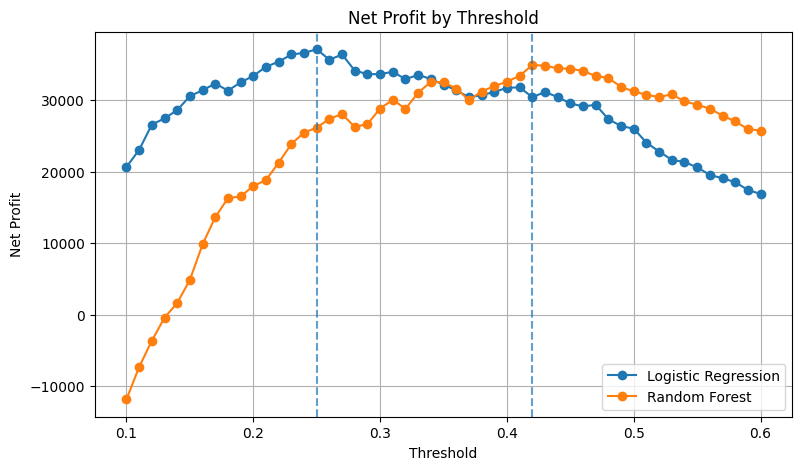

In [357]:
plt.figure(figsize=(9,5))
plt.plot(log_results_df['threshold'], log_results_df['net_profit'], marker='o', label='Logistic Regression')
plt.plot(rf_results_df['threshold'], rf_results_df['net_profit'], marker='o', label='Random Forest')
plt.axvline(best_log['threshold'], linestyle='--', alpha=0.7)
plt.axvline(best_rf['threshold'], linestyle='--', alpha=0.7)
plt.title('Net Profit by Threshold')
plt.xlabel('Threshold')
plt.ylabel('Net Profit')
plt.legend()
plt.grid(True)
plt.show()

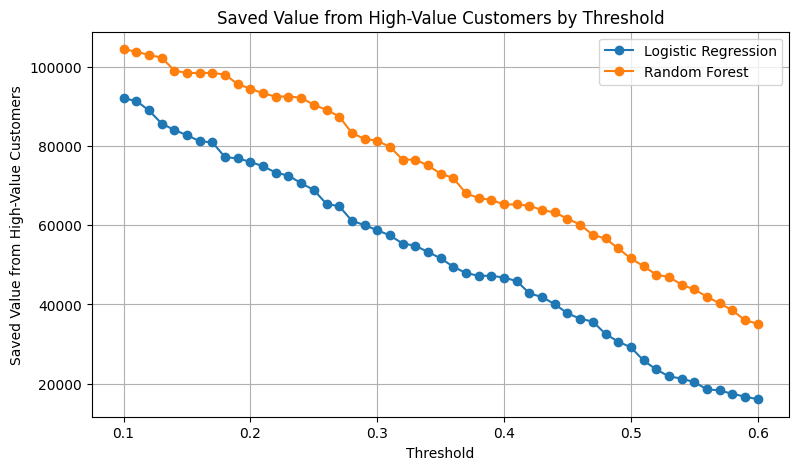

In [358]:
plt.figure(figsize=(9,5))
plt.plot(log_results_df['threshold'], log_results_df['saved_value_high_value'], marker='o', label='Logistic Regression')
plt.plot(rf_results_df['threshold'], rf_results_df['saved_value_high_value'], marker='o', label='Random Forest')
plt.title('Saved Value from High-Value Customers by Threshold')
plt.xlabel('Threshold')
plt.ylabel('Saved Value from High-Value Customers')
plt.legend()
plt.grid(True)
plt.show()

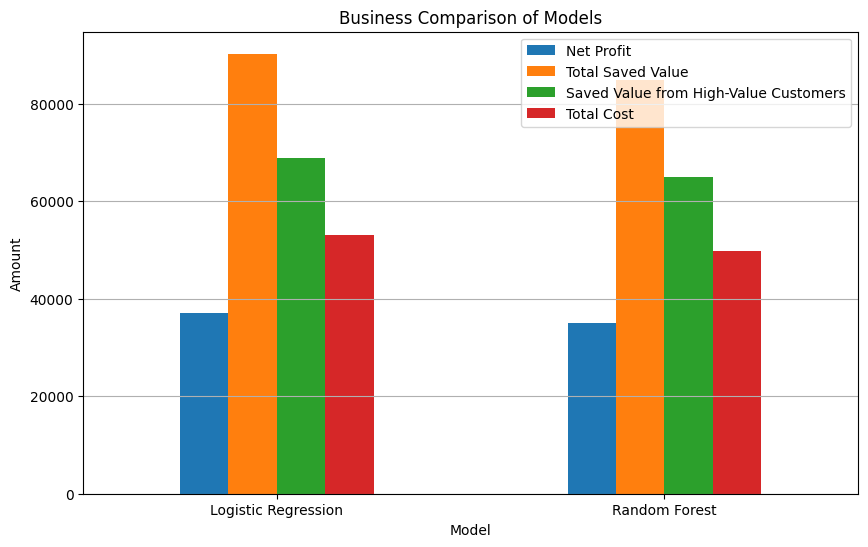

In [359]:
plot_df = comparison_df.set_index('Model')[[
    'Net Profit',
    'Total Saved Value',
    'Saved Value from High-Value Customers',
    'Total Cost'
]]

plot_df.plot(kind='bar', figsize=(10,6))
plt.title('Business Comparison of Models')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

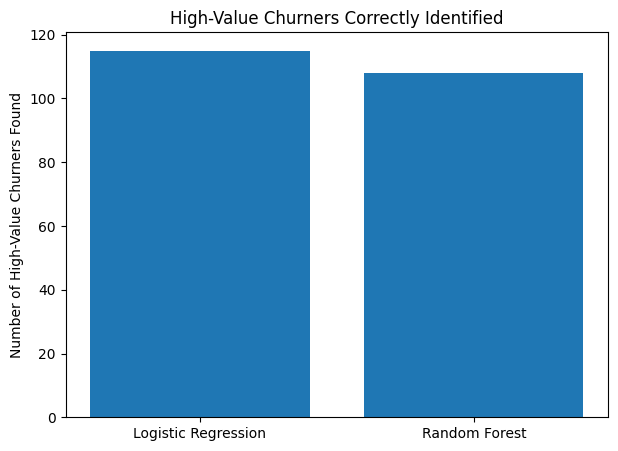

In [360]:
plt.figure(figsize=(7,5))
plt.bar(comparison_df['Model'], comparison_df['High-Value Churners Found'])
plt.title('High-Value Churners Correctly Identified')
plt.ylabel('Number of High-Value Churners Found')
plt.show()

In [361]:
if best_rf['net_profit'] > best_log['net_profit']:
    winner = "Random Forest"
elif best_rf['net_profit'] < best_log['net_profit']:
    winner = "Logistic Regression"
else:
    winner = "Both models perform equally in net profit"

print("Best business model:", winner)

Best business model: Logistic Regression


In [362]:
print("\nBUSINESS INTERPRETATION\n")

print(
    f"Logistic Regression achieved its highest net profit at threshold {best_log['threshold']:.2f}, "
    f"targeting {int(best_log['targeted_customers'])} customers and generating a net profit of "
    f"{best_log['net_profit']:,.2f}."
)

print(
    f"Random Forest achieved its highest net profit at threshold {best_rf['threshold']:.2f}, "
    f"targeting {int(best_rf['targeted_customers'])} customers and generating a net profit of "
    f"{best_rf['net_profit']:,.2f}."
)

if best_rf['net_profit'] > best_log['net_profit']:
    print(
        f"From a business perspective, Random Forest is the better model because it delivers "
        f"{best_rf['net_profit'] - best_log['net_profit']:,.2f} more net profit than Logistic Regression."
    )
else:
    print(
        f"From a business perspective, Logistic Regression is the better model because it delivers "
        f"{best_log['net_profit'] - best_rf['net_profit']:,.2f} more net profit than Random Forest."
    )

if best_rf['saved_value_high_value'] > best_log['saved_value_high_value']:
    print(
        f"Random Forest also performs better in protecting high-value customers, saving "
        f"{best_rf['saved_value_high_value'] - best_log['saved_value_high_value']:,.2f} more value from high-value churners."
    )
else:
    print(
        f"Logistic Regression performs better in protecting high-value customers, saving "
        f"{best_log['saved_value_high_value'] - best_rf['saved_value_high_value']:,.2f} more value from high-value churners."
    )


BUSINESS INTERPRETATION

Logistic Regression achieved its highest net profit at threshold 0.25, targeting 733 customers and generating a net profit of 37,134.23.
Random Forest achieved its highest net profit at threshold 0.42, targeting 689 customers and generating a net profit of 34,919.35.
From a business perspective, Logistic Regression is the better model because it delivers 2,214.88 more net profit than Random Forest.
Logistic Regression performs better in protecting high-value customers, saving 3,951.18 more value from high-value churners.


In [370]:
#used in the powerBI Dashboard
import os
os.listdir()

['.config',
 'model_comparison.csv',
 'sample_data',
 'final_dataset.csv',
 'customer_predictions.csv',
 'threshold_results.csv']

In [364]:

log_results_df['Model'] = 'Logistic Regression'
rf_results_df['Model'] = 'Random Forest'

import pandas as pd
threshold_results = pd.concat([log_results_df, rf_results_df], ignore_index=True)


eval_df.to_csv("customer_predictions.csv", index=False)
threshold_results.to_csv("threshold_results.csv", index=False)
comparison_df.to_csv("model_comparison.csv", index=False)

In [365]:
from google.colab import files

files.download("customer_predictions.csv")
files.download("threshold_results.csv")
files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [366]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,ServicesCount,CLV_Rank,AvgRevenuePerMonth,HasFiber,IsMonthToMonth,IsElectronicCheck,AvgRevenuePerMonth_Rank,log_prob,tenure_group,RetentionCost
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,1,Low,14.92,0,1,1,Low,NaN,0-12,1.4925
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,3,High,53.99,0,0,0,Mid,NaN,25-48,96.8150
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,3,Low,36.05,0,1,0,Mid,NaN,0-12,5.3850
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,3,High,40.02,0,0,0,Mid,NaN,25-48,95.1750
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,Low,50.55,1,1,1,Mid,NaN,0-12,7.0700


In [367]:
df.to_csv("final_dataset.csv", index=False)

In [368]:
from google.colab import files
files.download("final_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>